# Phase 2: Segmentation Exploration

Explore default rates and portfolio composition across key business segments.
Leave all work here — nothing in this notebook is the deliverable. Phase 2 logic lives in `pipeline/segment.py`.

Sections in order. Validate each segment against expected patterns before moving to the next.

## Section 1: Load and Verify

In [71]:
import pandas as pd
import numpy as np

# Loading clean data
df = pd.read_csv('/Users/gagepiercegaubert/Desktop/career_projects/lending-risk-intelligence/stages/02-clean/output/lending_risk_cleaned.csv')

# Verify required columns exist
assert 'is_default' in df.columns, "Missing is_default — run clean.py first"
assert 'crisis_period' in df.columns, "Missing crisis_period — run clean.py first"

print(f"Records: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Baseline default rate: {df['is_default'].mean():.2%}")

Records: 1,269,549
Columns: 93
Baseline default rate: 19.55%


## Section 2: Segment by Loan Grade (A–G)

Business question: How does default risk increase with credit tier?
Audit: Default rate should increase monotonically A → G.

In [72]:
result = (
    df.groupby('grade')['is_default'].agg(
        loan_count='count',
        default_count='sum',
        default_rate='mean',
    ).join(
        df.groupby('grade')['loan_amnt'].agg(
            avg_loan_amount='mean',
            total_portfolio_value='sum',
        )
    ).sort_index()
)

result.style.format({
    'default_rate': '{:.1%}',
    'avg_loan_amount': '${:,.0f}',
    'total_portfolio_value': '${:,.0f}',
})

,loan_count,default_count,default_rate,avg_loan_amount,total_portfolio_value
grade,,,,,
A,222504,12804,5.8%,"$14,014","$3,118,178,725"
B,370371,48062,13.0%,"$13,383","$4,956,616,050"
C,359591,78984,22.0%,"$14,363","$5,164,682,600"
D,188747,56420,29.9%,"$15,485","$2,922,779,600"
E,88818,33850,38.1%,"$17,843","$1,584,789,900"
F,30638,13716,44.8%,"$19,314","$591,756,225"
G,8880,4374,49.3%,"$20,630","$183,196,600"


**Note:** Average Loan Amount has a loose relationship with grade. It increases from A to G, but the signal is noisy. Default rate correlates cleanly with grade, increasing from A to G. Total Portfolio Value is bell-curve shaped with a heavy tail toward lower grades. Visuals below confirm these patterns.

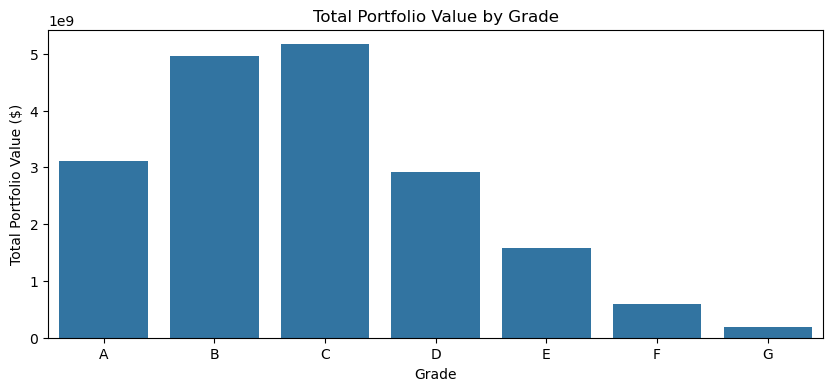

In [73]:
# Visualizing default rate by total portfolio value with a dist
import matplotlib.pyplot as plt
import seaborn as sns

grade_seg = df.groupby('grade')['loan_amnt'].sum().reset_index()
grade_seg.columns = ['grade', 'total_portfolio_value']

plt.figure(figsize=(10, 4))
sns.barplot(data=grade_seg, x='grade', y='total_portfolio_value')
plt.title('Total Portfolio Value by Grade')
plt.xlabel('Grade')
plt.ylabel('Total Portfolio Value ($)')
plt.show()

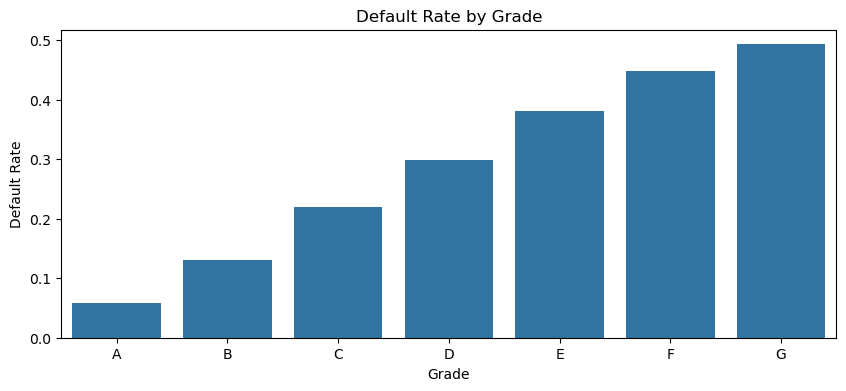

In [74]:
# A visual for default rate by grade
grade_default = df.groupby('grade')['is_default'].mean().reset_index()
grade_default.columns = ['grade', 'default_rate']

plt.figure(figsize=(10, 4))
sns.barplot(data=grade_default, x='grade', y='default_rate')
plt.title('Default Rate by Grade')
plt.xlabel('Grade')
plt.ylabel('Default Rate')
plt.show()

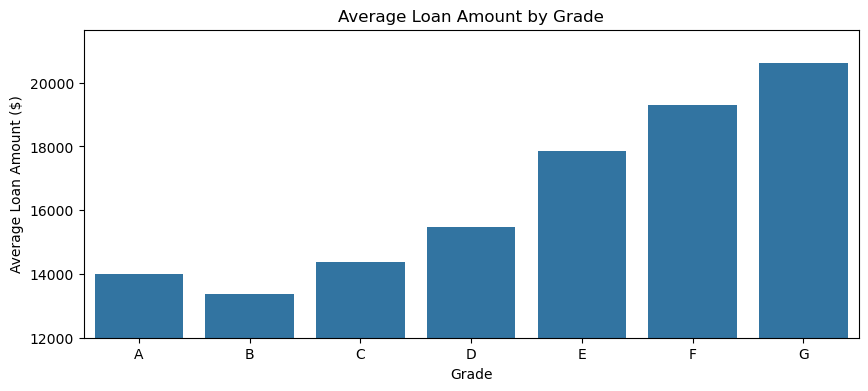

In [75]:
# A visual for average loan amount by grade starting at $10,000
grade_loan = df.groupby('grade')['loan_amnt'].mean().reset_index()
grade_loan.columns = ['grade', 'avg_loan_amount']

plt.figure(figsize=(10, 4))
sns.barplot(data=grade_loan, x='grade', y='avg_loan_amount')
plt.title('Average Loan Amount by Grade')
plt.xlabel('Grade')
plt.ylabel('Average Loan Amount ($)')
plt.ylim(12000, None)  # Start y-axis at $12,000
plt.show()

**Note:** B Grade has a lower average loan amount than A, which looks counterintuitive. More likely this is a platform selection effect. B and C grades are the most common borrower profile on Lending Club, which pulls the average down. Not a data quality issue.

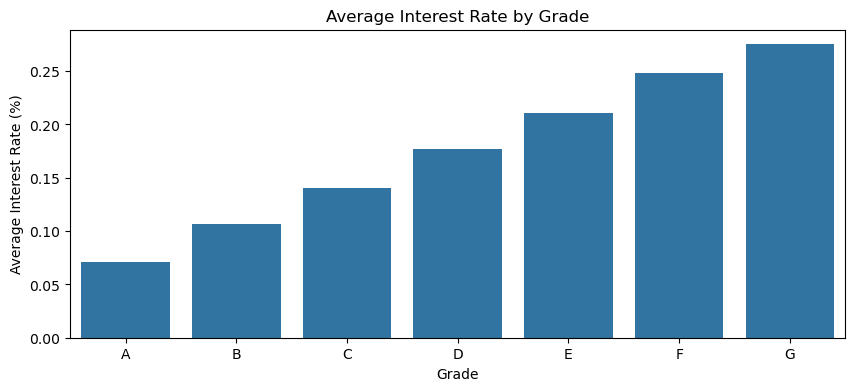

In [76]:
# Now Loan Rate by Grade
grade_rate = df.groupby('grade')['int_rate'].mean().reset_index()
grade_rate.columns = ['grade', 'avg_int_rate']

plt.figure(figsize=(10, 4))
sns.barplot(data=grade_rate, x='grade', y='avg_int_rate')
plt.title('Average Interest Rate by Grade')
plt.xlabel('Grade')
plt.ylabel('Average Interest Rate (%)')
plt.show()

**Note:** The relation here is more clear. Interest Rate increase as grade goes from A to G.

/var/folders/k8/0lnzlpcs1bn0sntqz4v2ryh40000gn/T/ipykernel_25107/3449308292.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



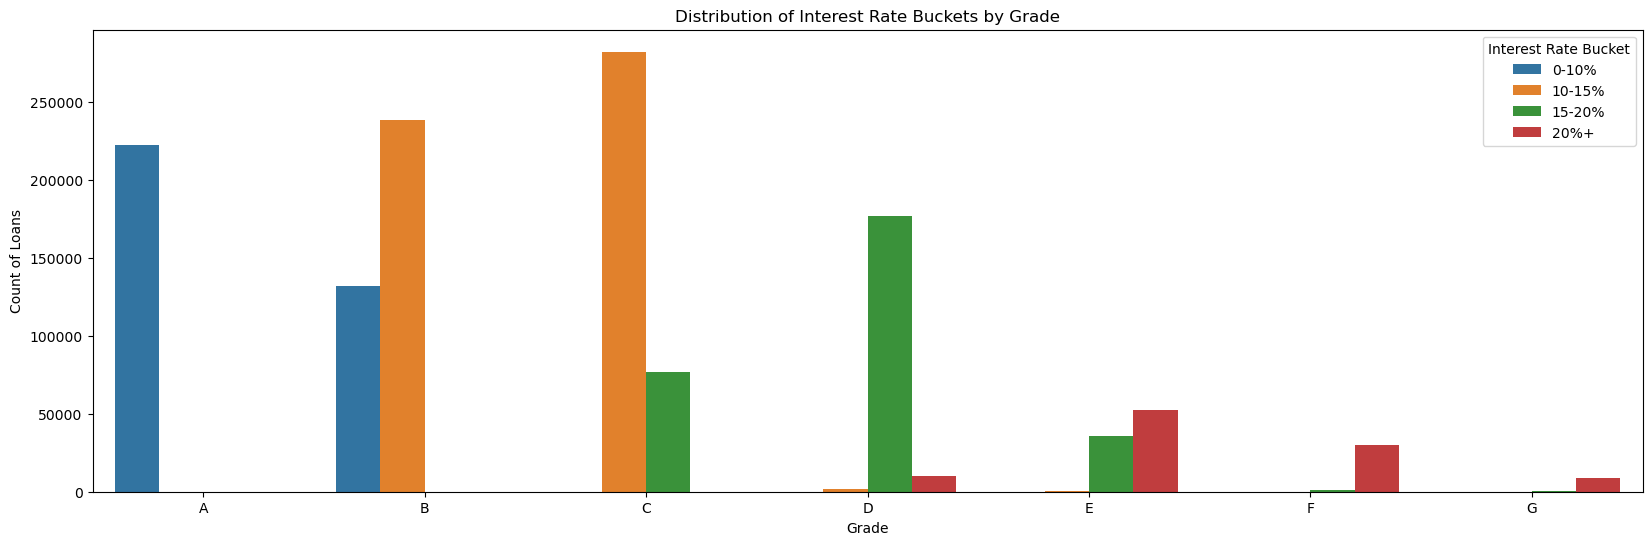

In [77]:
# Interest rate buckets by grade
df['int_rate_bucket'] = pd.cut(df['int_rate'], bins=[0, 0.10, 0.15, 0.20, 1.0], labels=['0-10%', '10-15%', '15-20%', '20%+'])
int_rate_dist = df.groupby(['grade', 'int_rate_bucket']).size().reset_index(name='count')

plt.figure(figsize=(20, 6))
sns.barplot(data=int_rate_dist, x='grade', y='count', hue='int_rate_bucket')
plt.title('Distribution of Interest Rate Buckets by Grade')
plt.xlabel('Grade')
plt.ylabel('Count of Loans')
plt.legend(title='Interest Rate Bucket')
plt.show()

**Note:** Interest rate buckets align tightly with grade. A borrowers concentrate in 0-10%, and by grade G nearly all loans are in the 20%+ bucket. Grade is effectively a proxy for interest rate band.

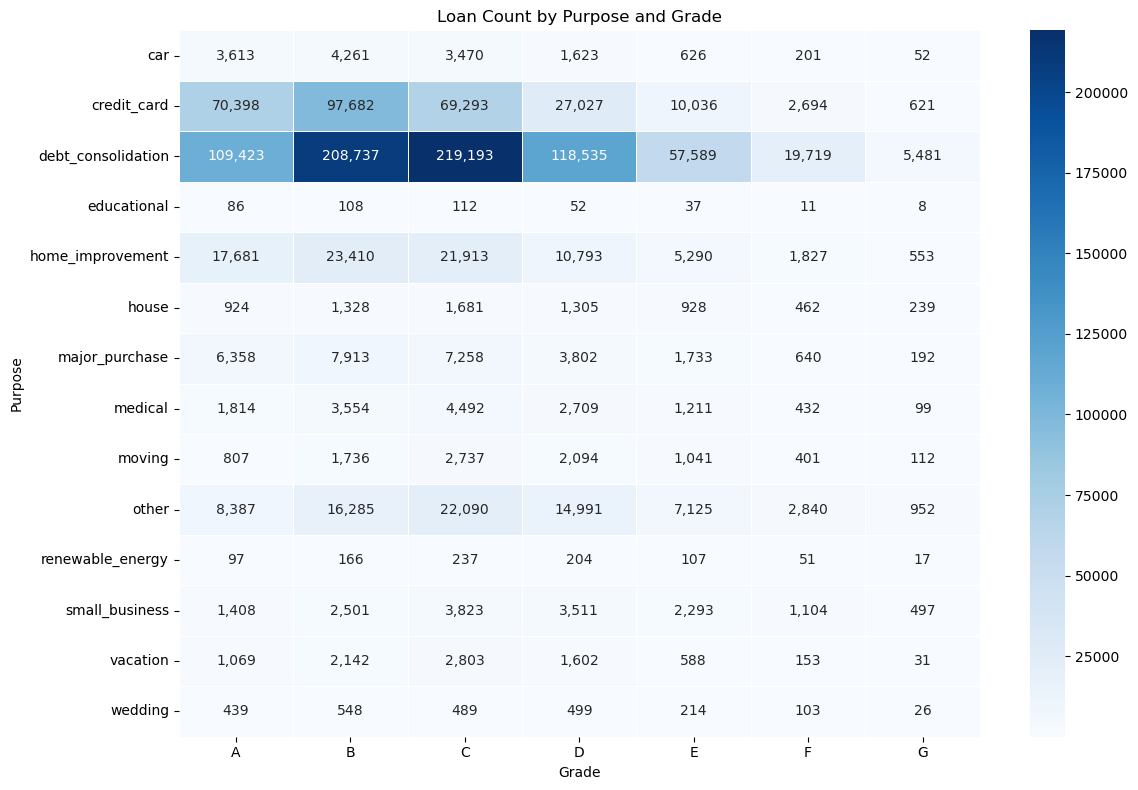

In [78]:
# A heatmap showing loan purpose by grade

import seaborn as sns
import matplotlib.pyplot as plt

purpose_pivot = df.groupby(['purpose', 'grade']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(
    purpose_pivot,
    fmt=',',
    annot=True,
    cmap='Blues',
    linewidths=0.5
)
plt.title('Loan Count by Purpose and Grade')
plt.ylabel('Purpose')
plt.xlabel('Grade')
plt.tight_layout()
plt.show()

**Note:** It seems Debt Consolidation is the most common loan purpose across all grades, followed by Credit Card and Home Improvement. The distribution of loan purposes is relatively similar across grades, although there may be some variation in the proportions of each purpose within each grade.

/var/folders/k8/0lnzlpcs1bn0sntqz4v2ryh40000gn/T/ipykernel_25107/3991438977.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



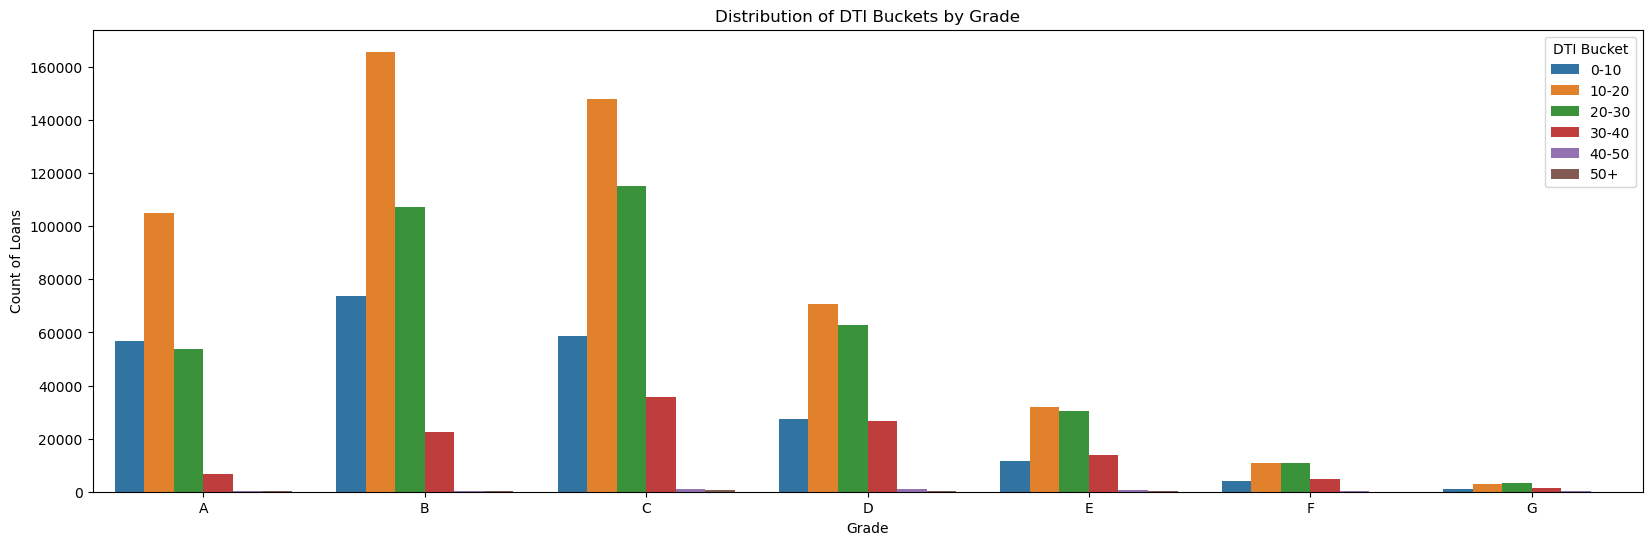

In [79]:
# Visualizing Debt to Income Ratio with bins by Grade

df['dti_bucket'] = pd.cut(df['dti'], bins=[0, 10, 20, 30, 40, 50, np.inf], labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50+'])
dti_dist = df.groupby(['grade', 'dti_bucket']).size().reset_index(name='count')
plt.figure(figsize=(20, 6))
sns.barplot(data=dti_dist, x='grade', y='count', hue='dti_bucket')
plt.title('Distribution of DTI Buckets by Grade')
plt.xlabel('Grade')
plt.ylabel('Count of Loans')
plt.legend(title='DTI Bucket')
plt.show()

**Explanatory Note:** DTI (Debt-to-Income ratio) measures monthly debt payments relative to monthly gross income. A higher DTI means less financial cushion, which increases default risk.

**Note:** The DTI distribution by grade is relatively flat. Most grades show a similar spread, with concentration in the 10-30 range. DTI alone does not cleanly separate grade, suggesting lenders use it alongside other factors (credit score, income) rather than as a standalone cutoff.

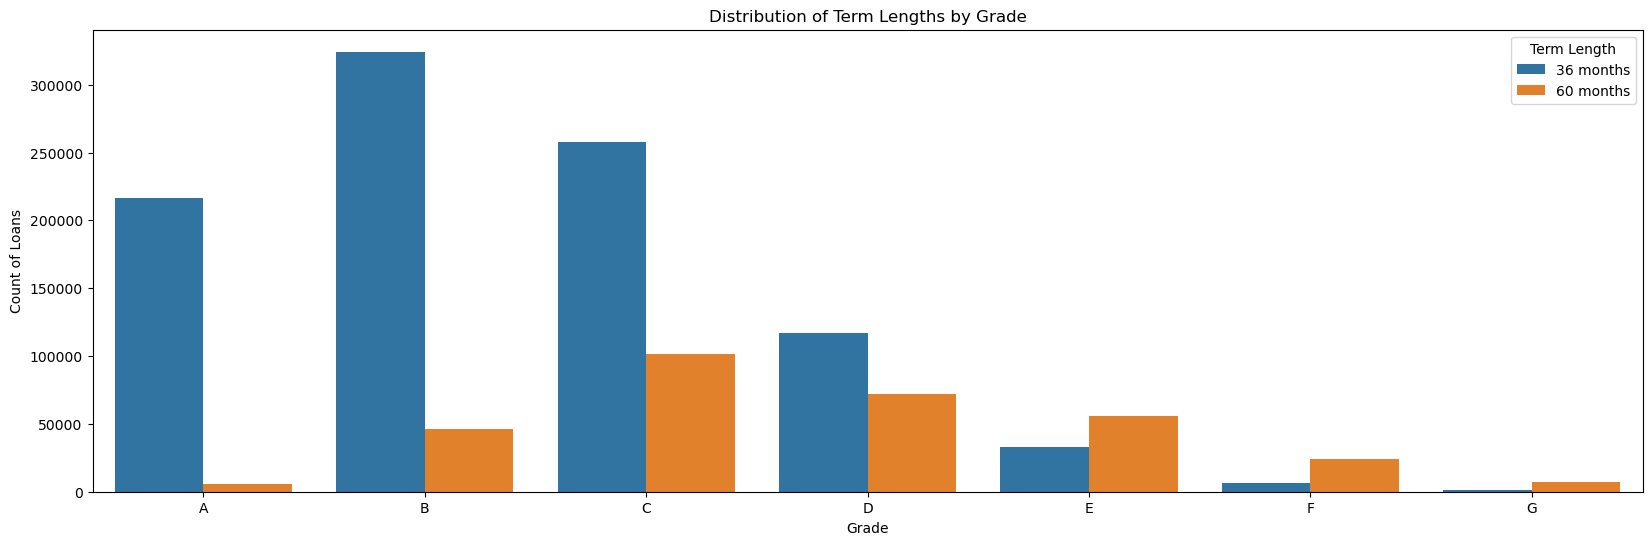

In [80]:
# Visualizing Term Lengths for the purpose of Duration Risks
term_dist = df.groupby(['grade', 'term']).size().reset_index(name='count')
plt.figure(figsize=(20, 6))
sns.barplot(data=term_dist, x='grade', y='count', hue='term')
plt.title('Distribution of Term Lengths by Grade')
plt.xlabel('Grade')
plt.ylabel('Count of Loans')
plt.legend(title='Term Length')
plt.show()

**Note:** 36-month loans dominate higher grades (A, B), while 60-month loans make up a larger share in lower grades (E, F, G). Higher-risk borrowers likely self-select into longer terms to lower monthly payments, but longer loans mean more exposure to default events over time.

/var/folders/k8/0lnzlpcs1bn0sntqz4v2ryh40000gn/T/ipykernel_25107/2731784874.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



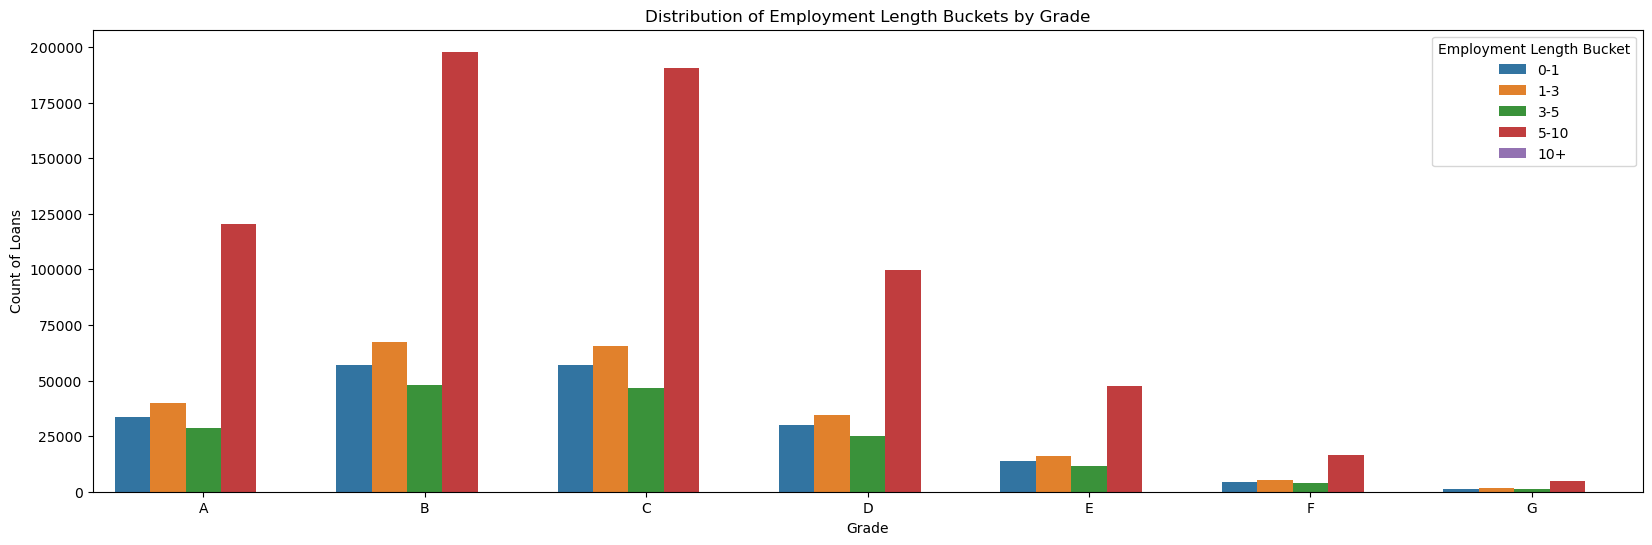

In [81]:
# Employment length Bins by grade visualized
emp_length_num = df['emp_length'].str.extract(r'(\d+)')[0].astype(float)
emp_length_num = emp_length_num.mask(df['emp_length'].eq('< 1 year'), 0.5)

df['emp_length_bucket'] = pd.cut(
    emp_length_num,
    bins=[0, 1, 3, 5, 10, np.inf],
    labels=['0-1', '1-3', '3-5', '5-10', '10+'],
    include_lowest=True
)
emp_length_dist = df.groupby(['grade', 'emp_length_bucket']).size().reset_index(name='count')
plt.figure(figsize=(20, 6))
sns.barplot(data=emp_length_dist, x='grade', y='count', hue='emp_length_bucket')
plt.title('Distribution of Employment Length Buckets by Grade')
plt.xlabel('Grade')
plt.ylabel('Count of Loans')
plt.legend(title='Employment Length Bucket')
plt.show()


**Note:** The 10+ year employment bucket is the largest across all grades. Longer tenure signals income stability. Distribution is otherwise fairly even, suggesting employment length alone is a weak grade predictor.

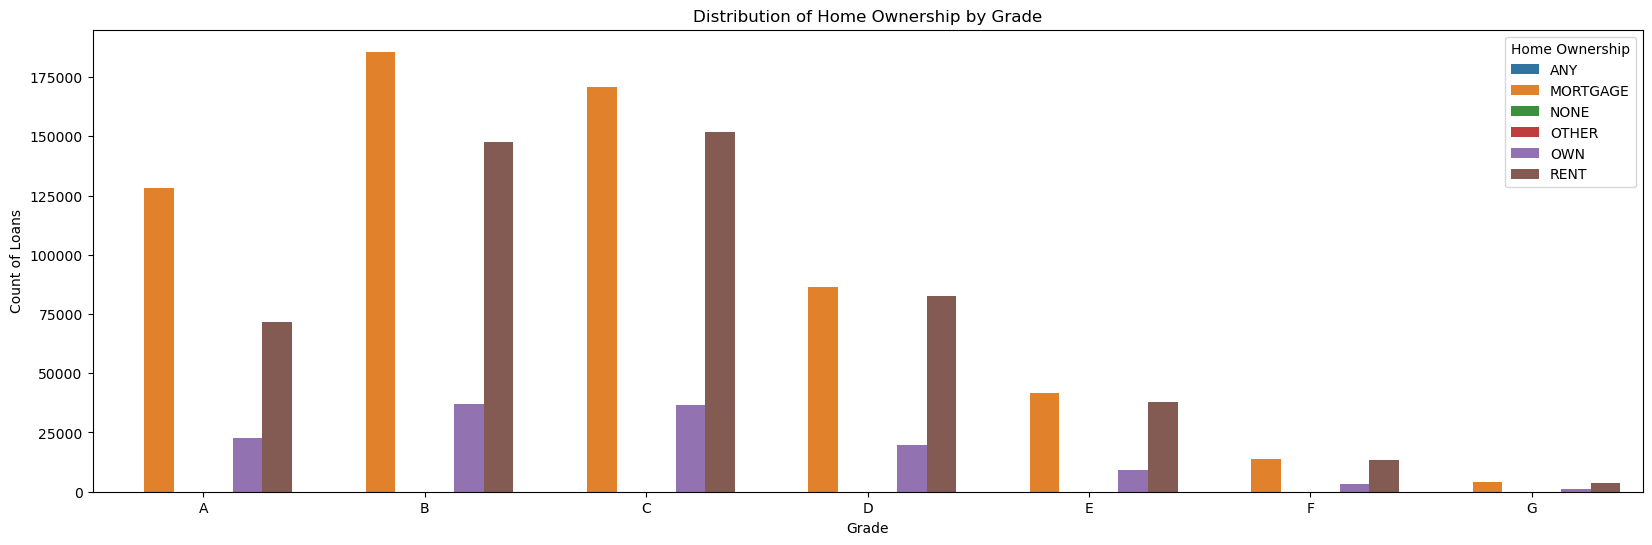

In [82]:
# Home ownership distribution by grade visualized
home_ownership_dist = df.groupby(['grade', 'home_ownership']).size().reset_index(name='count')
plt.figure(figsize=(20, 6))
sns.barplot(data=home_ownership_dist, x='grade', y='count', hue='home_ownership')
plt.title('Distribution of Home Ownership by Grade')
plt.xlabel('Grade')
plt.ylabel('Count of Loans')
plt.legend(title='Home Ownership')
plt.show()

**Note:** MORTGAGE and RENT dominate across all grades. The share of RENT increases slightly in lower grades, consistent with the expectation that homeowners with mortgages tend to have stronger overall credit profiles than renters.

/var/folders/k8/0lnzlpcs1bn0sntqz4v2ryh40000gn/T/ipykernel_25107/308635987.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



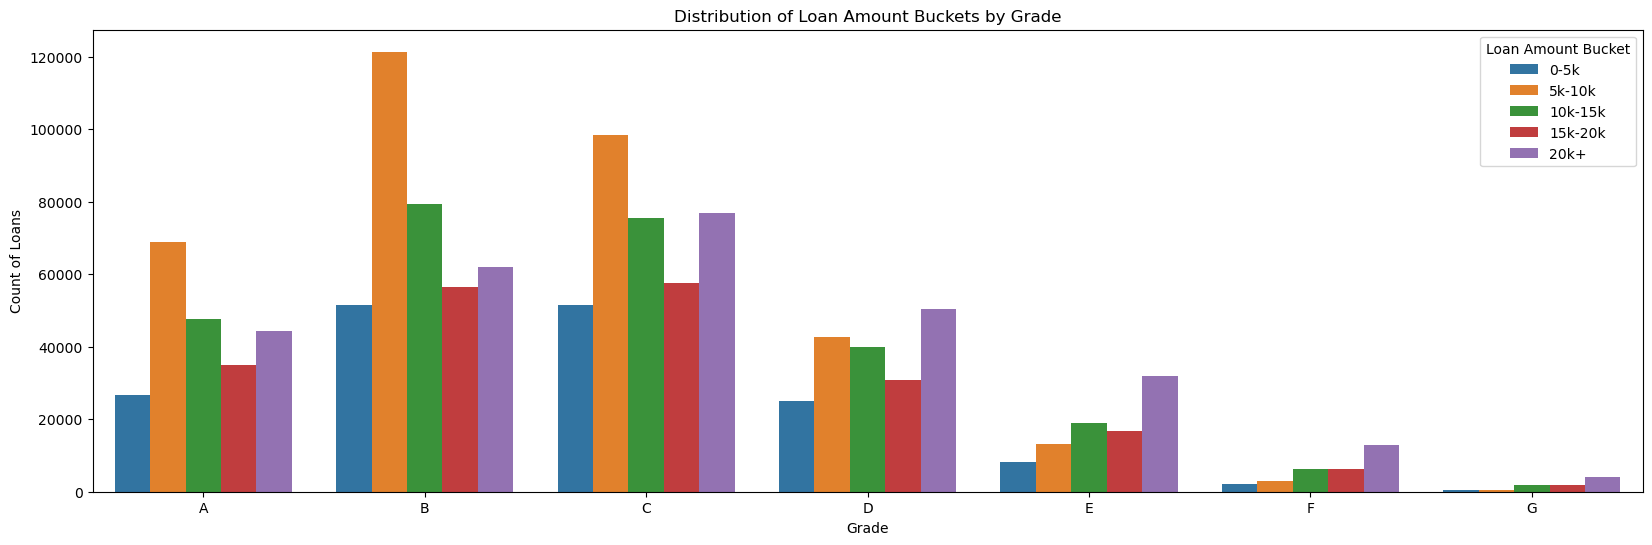

In [83]:
# Loan amount buckets by grade visualized
df['loan_amnt_bucket'] = pd.cut(df['loan_amnt'], bins=[0, 5000, 10000, 15000, 20000, np.inf], labels=['0-5k', '5k-10k', '10k-15k', '15k-20k', '20k+'])
loan_amnt_dist = df.groupby(['grade', 'loan_amnt_bucket']).size().reset_index(name='count')
plt.figure(figsize=(20, 6))
sns.barplot(data=loan_amnt_dist, x='grade', y='count', hue='loan_amnt_bucket')
plt.title('Distribution of Loan Amount Buckets by Grade')
plt.xlabel('Grade')
plt.ylabel('Count of Loans')
plt.legend(title='Loan Amount Bucket')
plt.show()

**Note:** There continues to be this interesting pattern where 'B' and 'C' Grade have a higher proportion of loans. I am sure again that this may be a data quality issue, but it makes me wonder if it is based on borrower profile.

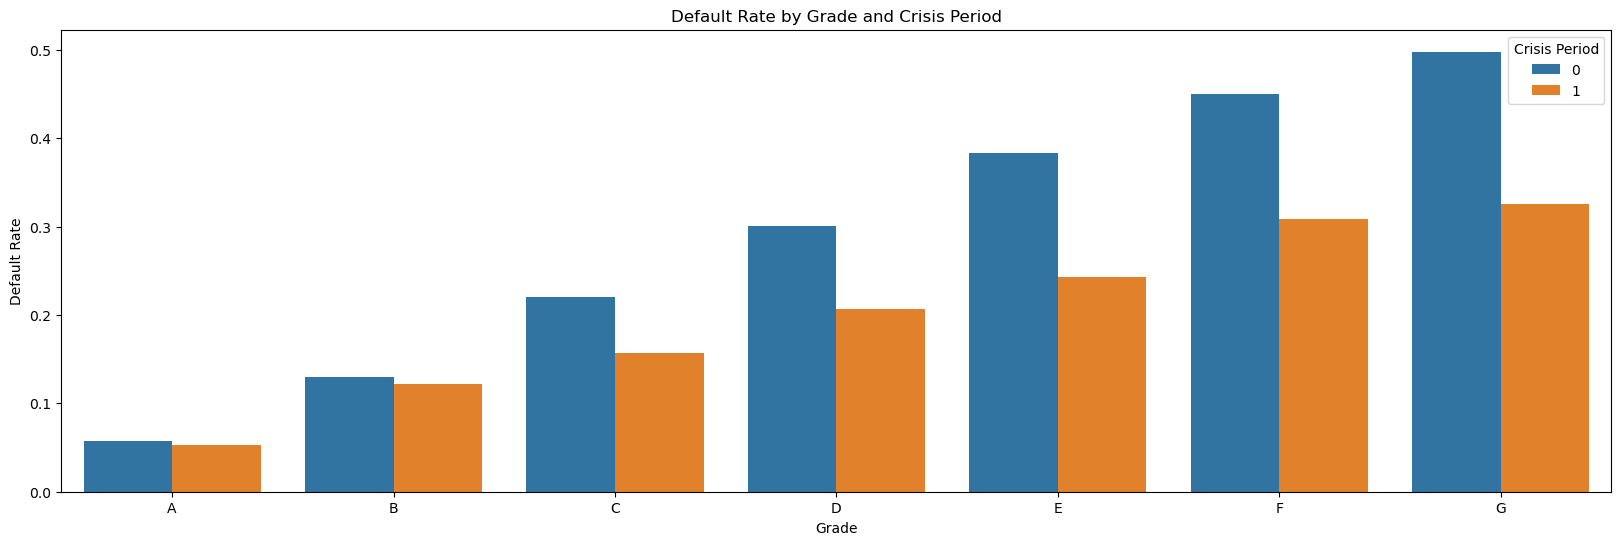

In [84]:
# Default rate by grade x crisis period visualized
default_crisis = df.groupby(['grade', 'crisis_period'])['is_default'].mean().reset_index()
default_crisis.columns = ['grade', 'crisis_period', 'default_rate']
plt.figure(figsize=(20, 6))
sns.barplot(data=default_crisis, x='grade', y='default_rate', hue='crisis_period')
plt.title('Default Rate by Grade and Crisis Period')
plt.xlabel('Grade')
plt.ylabel('Default Rate')
plt.legend(title='Crisis Period')
plt.show()

**Note:** With the data we have from this dataset, it seems that default rates were lower during the crisis period but based on historical context, we know that things like CDO^2s and other financial bank lending practices were a major contributor to the crisis along with a lack of data. After the Dodd-Frank Act was passed, there was a significant increase in data collection and reporting requirments. This is one of the most well known examples of survivorship bias.